In [4]:
import pandas as pd
from wcwidth import width

from data_loader import load_data
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

In [9]:
proj_path = Path.cwd().parent
data_path = proj_path / 'data'

In [10]:
df = load_data(data_path/'train.csv')
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [25]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order_month', 'Order_day', 'Order_year',
       'Ship_month', 'Ship_day', 'Ship_year'],
      dtype='str')

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Postal Code'] = df['Postal Code'].astype(str).replace('.0', '', regex=False)

In [13]:
df['Order_month'], df['Order_day'], df['Order_year'] = df['Order Date'].dt.month, df['Order Date'].dt.day, df['Order Date'].dt.year

df['Ship_month'], df['Ship_day'], df['Ship_year'] = df['Ship Date'].dt.month, df['Ship Date'].dt.day, df['Ship Date'].dt.year

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Order_month,Order_day,Order_year,Ship_month,Ship_day,Ship_year
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,8,2017,11,11,2017
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,8,2017,11,11,2017
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,12,2017,6,16,2017
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,11,2016,10,18,2016
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10,11,2016,10,18,2016


In [15]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Order_month,Order_day,Order_year,Ship_month,Ship_day,Ship_year
count,9800.000000,9800,9800,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-05 04:17:52.653061,230.769059,7.818469,15.486837,2016.724184,7.752245,15.895816,2016.739388
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,0.444000,1.000000,1.000000,2015.000000,1.000000,1.000000,2015.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,17.248000,5.000000,8.000000,2016.000000,5.000000,8.000000,2016.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,54.490000,9.000000,16.000000,2017.000000,9.000000,16.000000,2017.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,210.605000,11.000000,23.000000,2018.000000,11.000000,24.000000,2018.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,22638.480000,12.000000,31.000000,2018.000000,12.000000,31.000000,2019.000000
std,2829.160653,NaN,NaN,626.651875,3.281905,8.753733,1.123984,3.337933,8.804986,1.126837


In [16]:
df.isna().sum()
#only Postal Code has null data

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Order_month       0
Order_day         0
Order_year        0
Ship_month        0
Ship_day          0
Ship_year         0
dtype: int64

In [17]:
df[df['Postal Code'].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Order_month,Order_day,Order_year,Ship_month,Ship_day,Ship_year
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,12,5,2018,12,10,2018
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,...,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,11,7,2016,11,9,2016
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,...,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,4,6,2017,4,10,2017
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,1,23,2017,1,27,2017
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,Office Supplies,Art,4009 Highlighters,8.04,1,23,2017,1,27,2017
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,1,23,2017,1,27,2017
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,Office Supplies,Paper,Xerox 191,79.92,1,19,2018,1,23,2018
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,Office Supplies,Paper,Xerox 1881,12.28,1,19,2018,1,23,2018
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,1,19,2018,1,23,2018
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,1,19,2018,1,23,2018


In [18]:
# 05401 - Postal Code of Burlington, Vermont
df['Postal Code'] = df['Postal Code'].fillna('05401')

In [19]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Order_month      0
Order_day        0
Order_year       0
Ship_month       0
Ship_day         0
Ship_year        0
dtype: int64

In [20]:
df.nunique()

Row ID           9800
Order ID         4922
Order Date       1230
Ship Date        1326
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              529
State              49
Postal Code       627
Region              4
Product ID       1861
Category            3
Sub-Category       17
Product Name     1849
Sales            5757
Order_month        12
Order_day          31
Order_year          4
Ship_month         12
Ship_day           31
Ship_year           5
dtype: int64

Text(0.5, 1.0, 'Average price per order by Ship Mode')

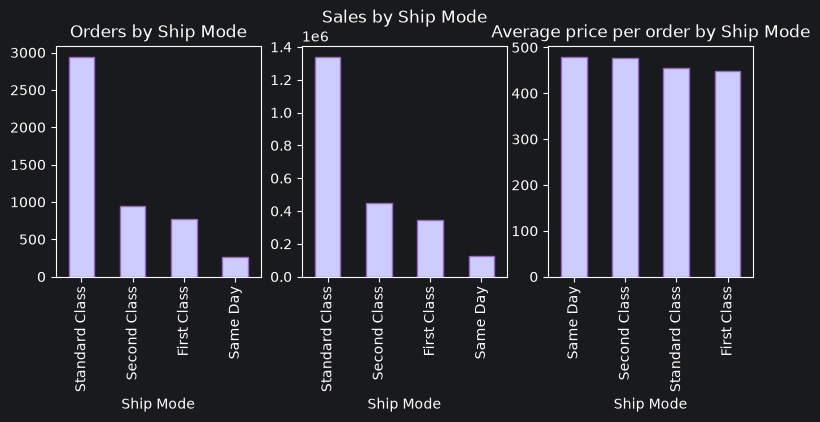

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(9,3))
df.groupby('Ship Mode')['Order ID'].nunique().sort_values(ascending = False).plot(kind='bar', ax=axes[0], color = '#CCCCFF', edgecolor = '#9966CC')
axes[0].set_title("Orders by Ship Mode")

df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending = False).plot(kind='bar', ax=axes[1], color = '#CCCCFF', edgecolor = '#9966CC')
axes[1].set_title("Sales by Ship Mode")

df.groupby(['Order ID', 'Ship Mode'])['Sales'].sum().reset_index().groupby('Ship Mode')['Sales'].mean().sort_values(ascending = False).plot(kind='bar', ax=axes[2], color = '#CCCCFF', edgecolor = '#9966CC')
axes[2].set_title("Average price per order by Ship Mode")

Text(0.5, 1.0, 'Average price per order by Segment')

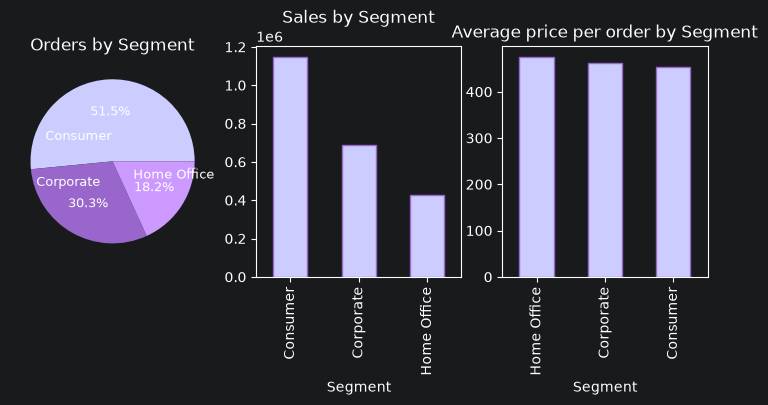

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(9,3))
df.groupby('Segment')['Order ID'].nunique().sort_values(ascending = False).plot(kind='pie', ax=axes[0], colors = ['#CCCCFF','#9966CC', '#CC99FF'], labeldistance = 0.3, autopct='%1.1f%%', textprops={'fontsize': 9})
axes[0].set_title("Orders by Segment")

df.groupby('Segment')['Sales'].sum().sort_values(ascending = False).plot(kind='bar', ax=axes[1], color = '#CCCCFF', edgecolor = '#9966CC')
axes[1].set_title("Sales by Segment")

df.groupby(['Order ID', 'Segment'])['Sales'].sum().reset_index().groupby('Segment')['Sales'].mean().sort_values(ascending = False).plot(kind='bar', ax=axes[2], color = '#CCCCFF', edgecolor = '#9966CC')
axes[2].set_title("Average price per order by Segment")

Text(0.5, 1.0, 'Average price per order by Category')

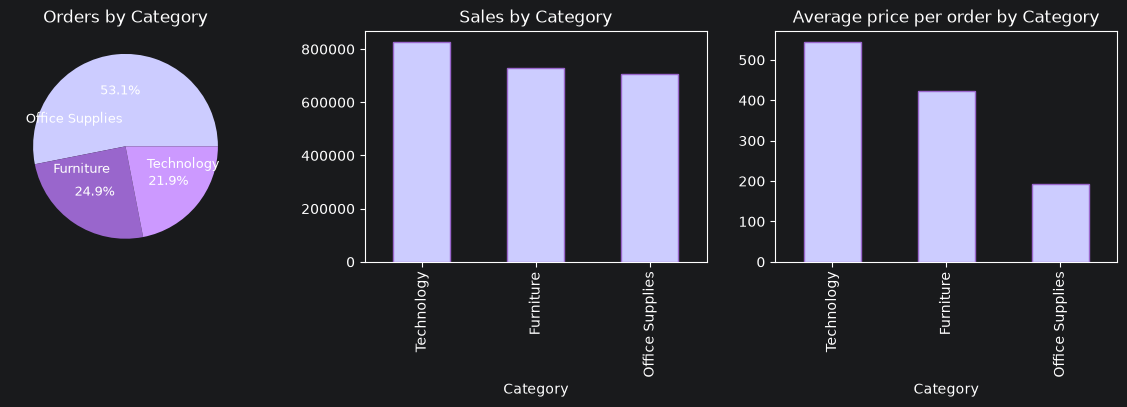

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
df.groupby('Category')['Order ID'].nunique().sort_values(ascending = False).plot(kind='pie', ax=axes[0], colors = ['#CCCCFF','#9966CC', '#CC99FF'], labeldistance = 0.3, autopct='%1.1f%%', textprops={'fontsize': 9})
axes[0].set_title("Orders by Category")

df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color = '#CCCCFF', edgecolor = '#9966CC')
axes[1].set_title("Sales by Category")

df.groupby(['Order ID', 'Category'])['Sales'].sum().reset_index().groupby('Category')['Sales'].mean().sort_values(
    ascending=False).plot(kind='bar', ax=axes[2], color = '#CCCCFF', edgecolor = '#9966CC')
axes[2].set_title("Average price per order by Category")

In [24]:
px.sunburst(df,
    path=['Category', 'Sub-Category'],
    values='Sales')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
df.groupby('Region')['Order ID'].nunique().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color = '#CCCCFF', edgecolor = '#9966CC')
axes[0].set_title("Orders by Region")

df.groupby('Region')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color = '#CCCCFF', edgecolor = '#9966CC')
axes[1].set_title("Sales by Region")

df.groupby(['Order ID', 'Region'])['Sales'].sum().reset_index().groupby('Region')['Sales'].mean().sort_values(
    ascending=False).plot(kind='bar', ax=axes[2], color = '#CCCCFF', edgecolor = '#9966CC')
axes[2].set_title("Region price per order by Category")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=1)
df.groupby('State')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color = '#CCCCFF', edgecolor = '#9966CC')
axes[0].set_title('Sales by States')

df.groupby('State')['Order ID'].nunique().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color = '#CCCCFF', edgecolor = '#9966CC')
axes[1].set_title('Orders by States')

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plt.subplots_adjust(hspace=1)
df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[0], color = '#CCCCFF', edgecolor = '#9966CC')
axes[0].set_title('Top-10 Cities by Sales')

df.groupby('City')['Sales'].sum().sort_values(ascending=True).head(10).plot(kind='bar', ax=axes[1], color = '#CCCCFF', edgecolor = '#9966CC')
axes[1].set_title('Bottom-10 Cities by Sales')